# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

## Prediksi Dropout Siswa - Jaya Jaya Institut

- **Nama:** Failasuf Indi M
- **Email:** failasufindi123@gmail.com
- **Id Dicoding:** failasuf

## Business Understanding

### Latar Belakang
**Jaya Jaya Institut** merupakan salah satu institusi pendidikan perguruan yang telah berdiri sejak tahun 2000. Hingga saat ini ia telah mencetak banyak lulusan dengan reputasi yang sangat baik. Akan tetapi, terdapat banyak juga siswa yang tidak menyelesaikan pendidikannya alias **dropout**.

Jumlah dropout yang tinggi ini tentunya menjadi salah satu masalah yang besar untuk sebuah institusi pendidikan. Oleh karena itu, Jaya Jaya Institut ingin **mendeteksi secepat mungkin** siswa yang mungkin akan melakukan dropout sehingga dapat diberi bimbingan khusus.

### Permasalahan Bisnis
1. Bagaimana **mengidentifikasi faktor-faktor utama** yang menyebabkan siswa melakukan dropout?
2. Bagaimana membangun **model machine learning** yang dapat memprediksi status siswa (Dropout, Enrolled, Graduate) secara akurat?
3. Bagaimana membuat **sistem monitoring** melalui dashboard agar pihak institusi dapat memantau performa siswa secara real-time?

### Cakupan Proyek
1. **Analisis Data (EDA):** Eksplorasi dataset siswa untuk menemukan pola dan insight terkait dropout.
2. **Preprocessing & Feature Engineering:** Menyiapkan data untuk pemodelan, termasuk handling class imbalance.
3. **Modeling:** Melatih dan membandingkan beberapa model klasifikasi (Logistic Regression, Random Forest, Gradient Boosting).
4. **Evaluasi:** Mengevaluasi performa model dengan metrik yang relevan (Accuracy, F1, Recall, ROC-AUC).
5. **Dashboard:** Membuat business dashboard menggunakan Google Looker Studio.
6. **Prototype:** Membangun prototype prediksi menggunakan Streamlit dan men-deploy ke Streamlit Community Cloud.

## Persiapan

### Menyiapkan library yang dibutuhkan

Berikut adalah library utama yang digunakan:
- **pandas & numpy**: Manipulasi dan analisis data
- **matplotlib & seaborn**: Visualisasi data
- **scikit-learn**: Preprocessing, modeling, dan evaluasi
- **imbalanced-learn**: Handling class imbalance dengan SMOTE
- **joblib**: Menyimpan dan memuat model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
print("Library berhasil dimuat!")

Library berhasil dimuat!


### Menyiapkan data yang akan digunakan

Dataset diambil dari repository Dicoding yang berisi data performa siswa di berbagai program studi. Dataset ini berisi informasi yang diketahui pada saat pendaftaran siswa (jalur akademik, demografis, dan faktor sosial-ekonomi) serta performa akademik siswa pada akhir semester 1 dan 2.

In [2]:
# Load dataset
df = pd.read_csv('data.csv', delimiter=';')
print(f"Dataset berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]:,}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nDaftar kolom:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Dataset berhasil dimuat!
Jumlah baris: 4,424
Jumlah kolom: 37

Daftar kolom:
   1. Marital_status
   2. Application_mode
   3. Application_order
   4. Course
   5. Daytime_evening_attendance
   6. Previous_qualification
   7. Previous_qualification_grade
   8. Nacionality
   9. Mothers_qualification
  10. Fathers_qualification
  11. Mothers_occupation
  12. Fathers_occupation
  13. Admission_grade
  14. Displaced
  15. Educational_special_needs
  16. Debtor
  17. Tuition_fees_up_to_date
  18. Gender
  19. Scholarship_holder
  20. Age_at_enrollment
  21. International
  22. Curricular_units_1st_sem_credited
  23. Curricular_units_1st_sem_enrolled
  24. Curricular_units_1st_sem_evaluations
  25. Curricular_units_1st_sem_approved
  26. Curricular_units_1st_sem_grade
  27. Curricular_units_1st_sem_without_evaluations
  28. Curricular_units_2nd_sem_credited
  29. Curricular_units_2nd_sem_enrolled
  30. Curricular_units_2nd_sem_evaluations
  31. Curricular_units_2nd_sem_approved
  32. Curric

In [3]:
# Melihat 5 baris pertama
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
# Info dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

## Data Understanding

Pada tahap ini, kita akan melakukan eksplorasi data untuk memahami karakteristik dataset dan menemukan insight yang berguna.

### Pemeriksaan Kualitas Data

In [5]:
# Cek missing values dan duplikat
print("=" * 50)
print("PEMERIKSAAN KUALITAS DATA")
print("=" * 50)
print(f"\nMissing values per kolom:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  Tidak ada missing values! ✓")
else:
    print(missing[missing > 0])

print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")
print(f"\nStatistik deskriptif:")
df.describe().round(2)

PEMERIKSAAN KUALITAS DATA

Missing values per kolom:
  Tidak ada missing values! ✓

Jumlah baris duplikat: 0

Statistik deskriptif:


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,...,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,...,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,...,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,...,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,...,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,...,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,...,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


### Distribusi Target (Status Siswa)

Kolom target `Status` memiliki 3 kategori: **Dropout**, **Enrolled**, dan **Graduate**. Mari kita lihat distribusinya.

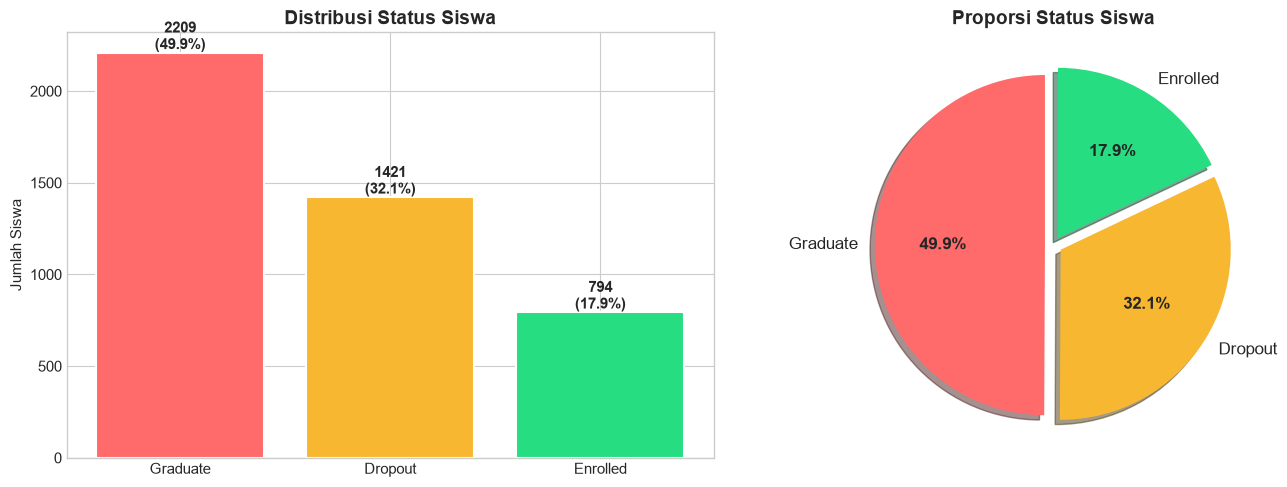


Insight: Dataset cukup imbalanced. Kelas Graduate mendominasi (49.9%),
sementara Enrolled hanya 17.9%. Perlu handling class imbalance.


In [6]:
# Distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#ff6b6b', '#f7b731', '#26de81']
target_counts = df['Status'].value_counts()
ax1 = axes[0]
bars = ax1.bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Distribusi Status Siswa', fontsize=14, fontweight='bold')
ax1.set_ylabel('Jumlah Siswa')
for bar, val in zip(bars, target_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
             f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(target_counts.values, labels=target_counts.index,
                                     colors=colors, autopct='%1.1f%%', startangle=90,
                                     explode=(0.05, 0.05, 0.05), shadow=True,
                                     textprops={'fontsize': 12})
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax2.set_title('Proporsi Status Siswa', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nInsight: Dataset cukup imbalanced. Kelas Graduate mendominasi ({target_counts['Graduate']/len(df)*100:.1f}%),")
print(f"sementara Enrolled hanya {target_counts['Enrolled']/len(df)*100:.1f}%. Perlu handling class imbalance.")

### Analisis Performa Akademik vs Status

Performa akademik (jumlah mata kuliah yang disetujui dan nilai rata-rata) merupakan indikator kunci dalam memprediksi dropout.

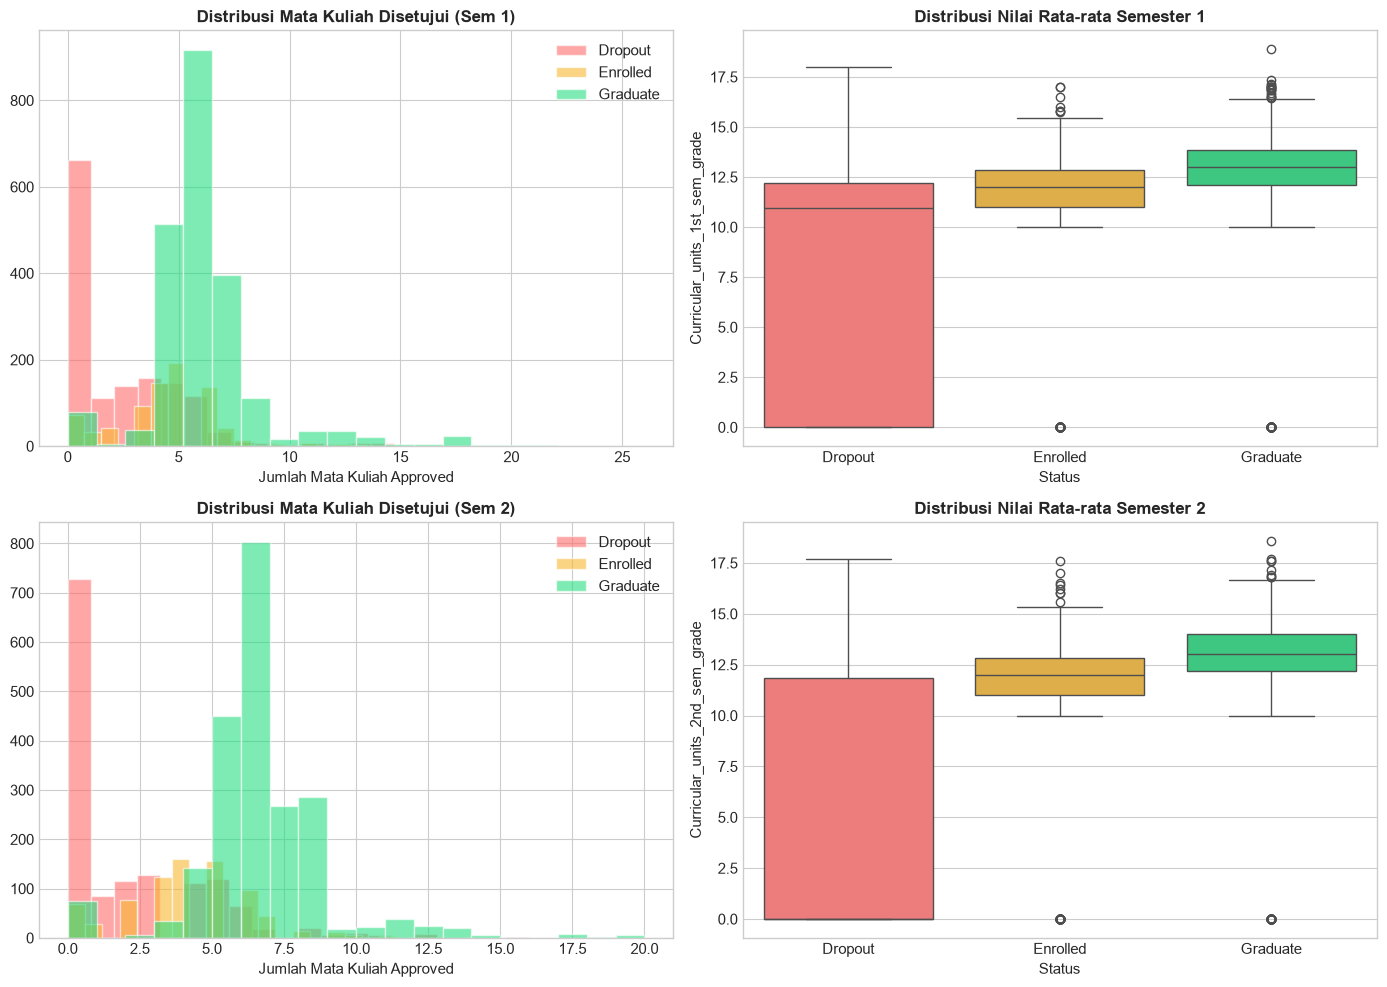


Rata-rata Performa Akademik per Status:
          Curricular_units_1st_sem_approved  Curricular_units_1st_sem_grade  Curricular_units_2nd_sem_approved  Curricular_units_2nd_sem_grade
Status                                                                                                                                        
Dropout                                2.55                            7.26                               1.94                            5.90
Enrolled                               4.32                           11.13                               4.06                           11.12
Graduate                               6.23                           12.64                               6.18                           12.70

Insight: Siswa Dropout memiliki rata-rata performa akademik yang jauh lebih rendah
dibandingkan Graduate, terutama pada jumlah mata kuliah yang approved dan nilai rata-rata.


In [7]:
# Performa akademik vs Status
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
status_order = ['Dropout', 'Enrolled', 'Graduate']
colors_status = {'Dropout': '#ff6b6b', 'Enrolled': '#f7b731', 'Graduate': '#26de81'}

# 1. Units approved sem 1
ax = axes[0, 0]
for status in status_order:
    data = df[df['Status'] == status]['Curricular_units_1st_sem_approved']
    ax.hist(data, bins=20, alpha=0.6, label=status, color=colors_status[status], edgecolor='white')
ax.set_title('Distribusi Mata Kuliah Disetujui (Sem 1)', fontsize=12, fontweight='bold')
ax.set_xlabel('Jumlah Mata Kuliah Approved')
ax.legend()

# 2. Grade sem 1
ax = axes[0, 1]
sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_grade',
            order=status_order, palette=colors_status, ax=ax)
ax.set_title('Distribusi Nilai Rata-rata Semester 1', fontsize=12, fontweight='bold')

# 3. Units approved sem 2
ax = axes[1, 0]
for status in status_order:
    data = df[df['Status'] == status]['Curricular_units_2nd_sem_approved']
    ax.hist(data, bins=20, alpha=0.6, label=status, color=colors_status[status], edgecolor='white')
ax.set_title('Distribusi Mata Kuliah Disetujui (Sem 2)', fontsize=12, fontweight='bold')
ax.set_xlabel('Jumlah Mata Kuliah Approved')
ax.legend()

# 4. Grade sem 2
ax = axes[1, 1]
sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_grade',
            order=status_order, palette=colors_status, ax=ax)
ax.set_title('Distribusi Nilai Rata-rata Semester 2', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print means
print("\nRata-rata Performa Akademik per Status:")
academic_cols = ['Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
                 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade']
print(df.groupby('Status')[academic_cols].mean().round(2).to_string())
print("\nInsight: Siswa Dropout memiliki rata-rata performa akademik yang jauh lebih rendah")
print("dibandingkan Graduate, terutama pada jumlah mata kuliah yang approved dan nilai rata-rata.")

### Analisis Faktor Finansial vs Status

Faktor finansial (status pembayaran, beasiswa, status debtor) juga berpengaruh terhadap risiko dropout.

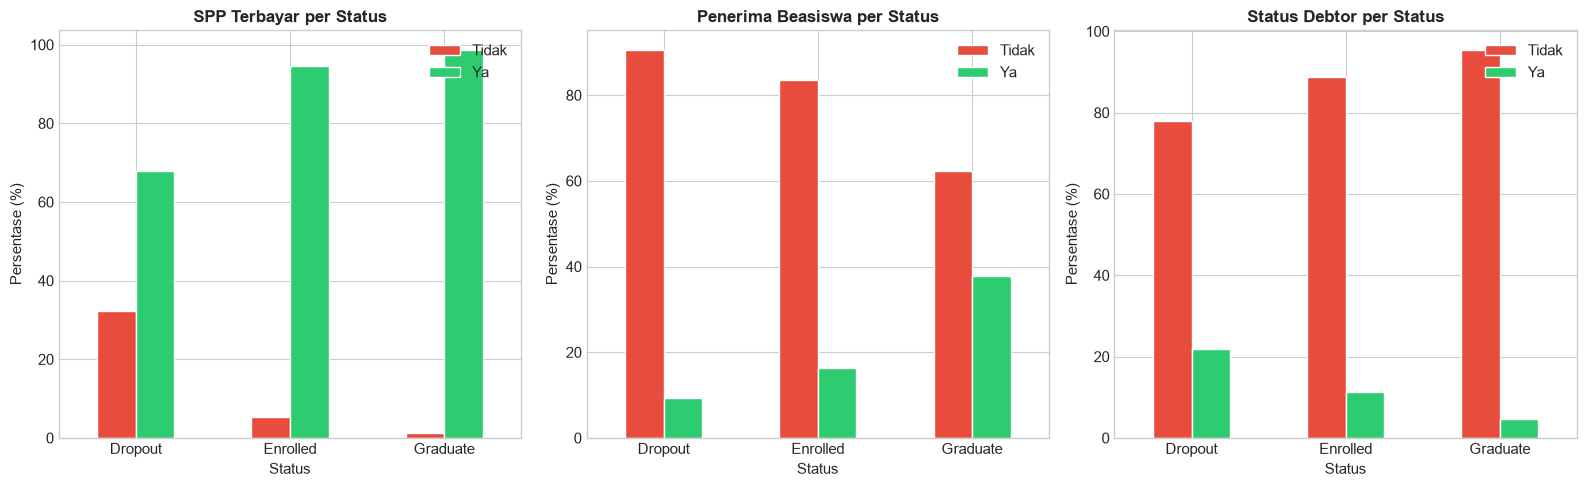


Insight:
- Hanya 68% siswa Dropout yang SPP-nya terbayar lunas, vs 99% Graduate.
- Hanya 9% siswa Dropout yang mendapat beasiswa, vs 38% Graduate.
- 22% siswa Dropout berstatus Debtor, vs hanya 5% Graduate.
=> Faktor finansial sangat berkorelasi dengan risiko dropout!


In [8]:
# Faktor finansial vs Status
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

financial_features = [
    ('Tuition_fees_up_to_date', 'SPP Terbayar'),
    ('Scholarship_holder', 'Penerima Beasiswa'),
    ('Debtor', 'Status Debtor')
]

for idx, (feat, title) in enumerate(financial_features):
    ax = axes[idx]
    ct = pd.crosstab(df['Status'], df[feat], normalize='index') * 100
    ct = ct.loc[status_order]
    ct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1)
    ax.set_title(f'{title} per Status', fontsize=12, fontweight='bold')
    ax.set_ylabel('Persentase (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(['Tidak', 'Ya'], loc='upper right')

plt.tight_layout()
plt.show()

print("\nInsight:")
print("- Hanya 68% siswa Dropout yang SPP-nya terbayar lunas, vs 99% Graduate.")
print("- Hanya 9% siswa Dropout yang mendapat beasiswa, vs 38% Graduate.")
print("- 22% siswa Dropout berstatus Debtor, vs hanya 5% Graduate.")
print("=> Faktor finansial sangat berkorelasi dengan risiko dropout!")

### Analisis Usia dan Dropout Rate per Program Studi

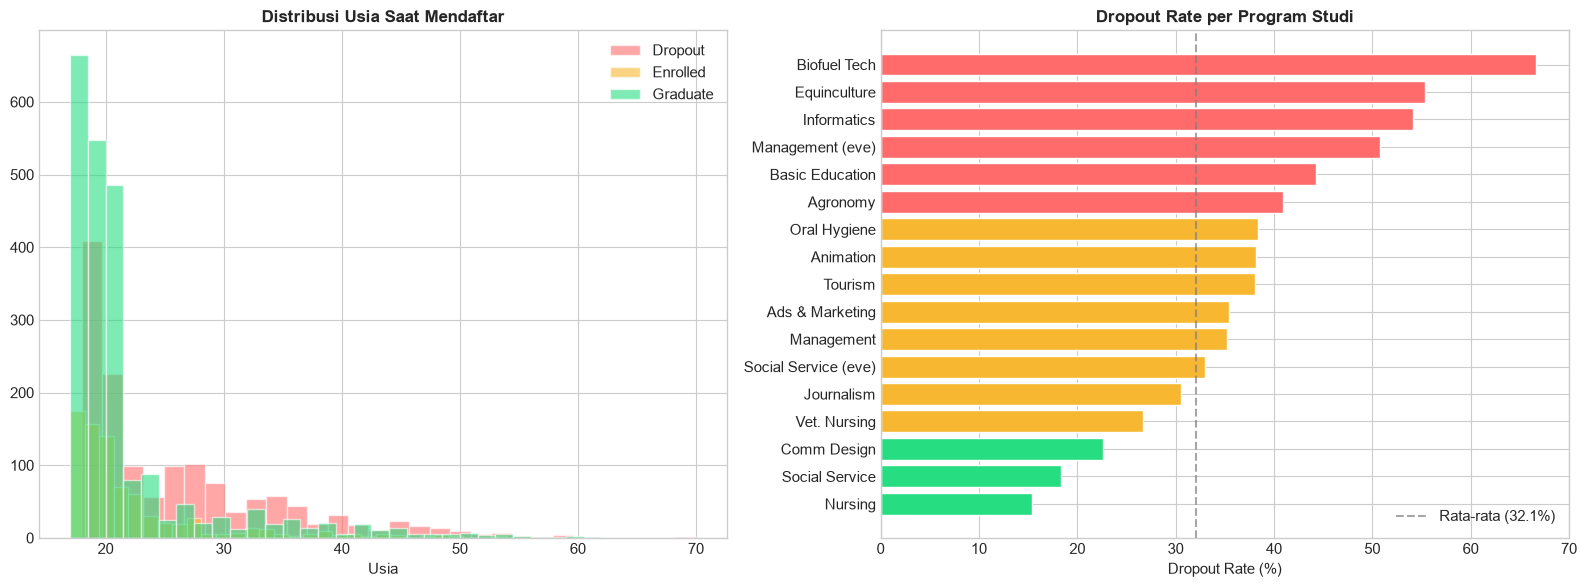


Insight:
- Rata-rata usia dropout (26.1 tahun)
  lebih tinggi dari Graduate (21.8 tahun)
- Program Biofuel Tech, Equinculture, dan Informatics memiliki dropout rate tertinggi (>50%)


In [9]:
# Usia dan Course analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Age distribution
ax = axes[0]
for status in status_order:
    data = df[df['Status'] == status]['Age_at_enrollment']
    ax.hist(data, bins=30, alpha=0.6, label=status, color=colors_status[status], edgecolor='white')
ax.set_title('Distribusi Usia Saat Mendaftar', fontsize=12, fontweight='bold')
ax.set_xlabel('Usia')
ax.legend()

# 2. Dropout rate per course
ax = axes[1]
course_names = {
    33: "Biofuel Tech", 171: "Animation", 8014: "Social Service (eve)",
    9003: "Agronomy", 9070: "Comm Design", 9085: "Vet. Nursing",
    9119: "Informatics", 9130: "Equinculture", 9147: "Management",
    9238: "Social Service", 9254: "Tourism", 9500: "Nursing",
    9556: "Oral Hygiene", 9670: "Ads & Marketing", 9773: "Journalism",
    9853: "Basic Education", 9991: "Management (eve)"
}

dropout_by_course = df.groupby('Course').apply(
    lambda x: (x['Status'] == 'Dropout').sum() / len(x) * 100
).sort_values(ascending=True)

course_labels = [course_names.get(c, str(c)) for c in dropout_by_course.index]
colors_bar = ['#ff6b6b' if v > 40 else '#f7b731' if v > 25 else '#26de81' for v in dropout_by_course.values]
ax.barh(course_labels, dropout_by_course.values, color=colors_bar, edgecolor='white')
ax.set_title('Dropout Rate per Program Studi', fontsize=12, fontweight='bold')
ax.set_xlabel('Dropout Rate (%)')
ax.axvline(x=32.1, color='gray', linestyle='--', alpha=0.7, label=f'Rata-rata ({32.1:.1f}%)')
ax.legend()

plt.tight_layout()
plt.show()

print("\nInsight:")
print(f"- Rata-rata usia dropout ({df[df['Status']=='Dropout']['Age_at_enrollment'].mean():.1f} tahun)")
print(f"  lebih tinggi dari Graduate ({df[df['Status']=='Graduate']['Age_at_enrollment'].mean():.1f} tahun)")
print("- Program Biofuel Tech, Equinculture, dan Informatics memiliki dropout rate tertinggi (>50%)")

### Korelasi antar Fitur Numerik

Heatmap korelasi membantu mengidentifikasi hubungan linear antar fitur.

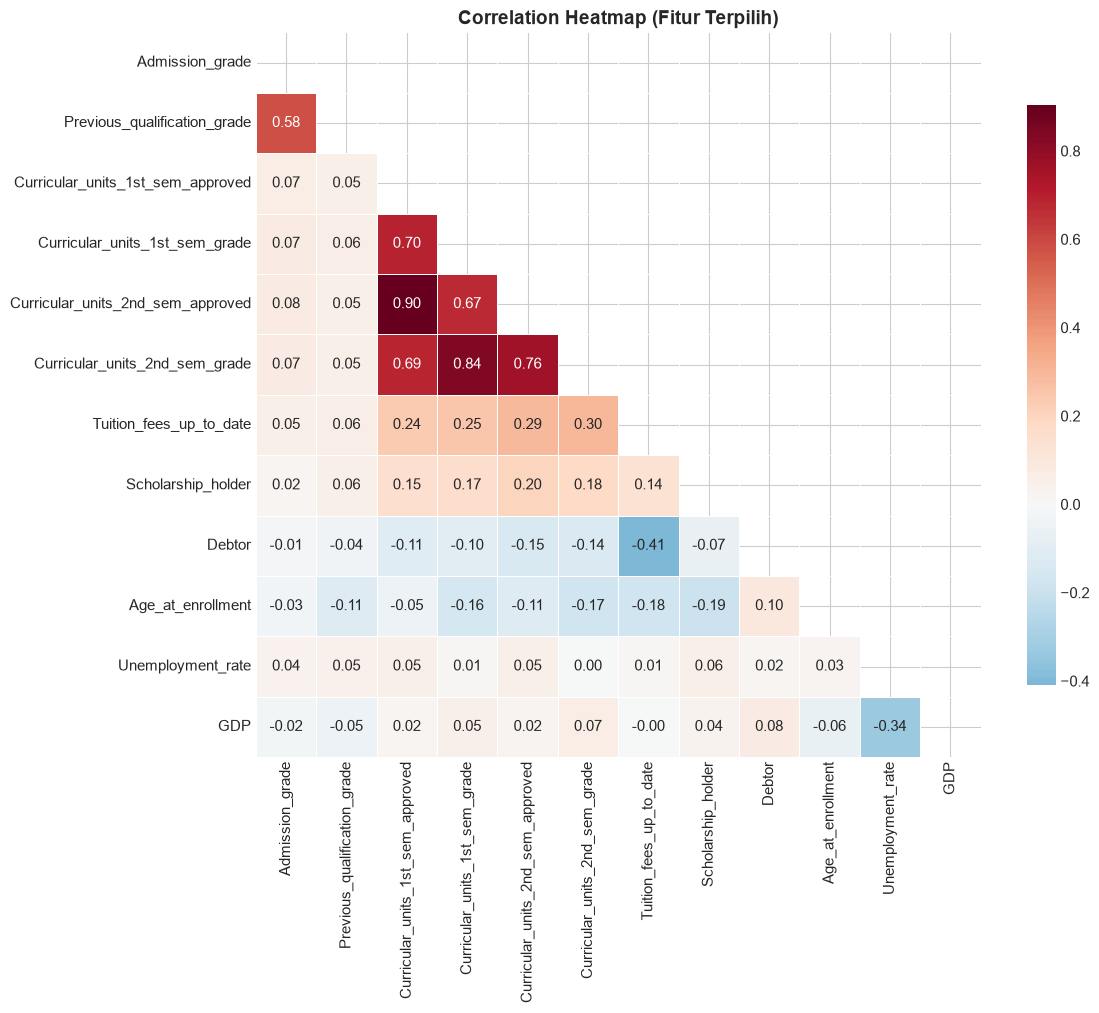


Insight: Terdapat korelasi positif kuat antara units approved sem 1 & sem 2,
serta antara grade sem 1 & sem 2, menunjukkan konsistensi performa akademik.


In [10]:
# Correlation heatmap (selected features)
selected_cols = [
    'Admission_grade', 'Previous_qualification_grade',
    'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
    'Tuition_fees_up_to_date', 'Scholarship_holder', 'Debtor',
    'Age_at_enrollment', 'Unemployment_rate', 'GDP'
]

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[selected_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Fitur Terpilih)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInsight: Terdapat korelasi positif kuat antara units approved sem 1 & sem 2,")
print("serta antara grade sem 1 & sem 2, menunjukkan konsistensi performa akademik.")

## Data Preparation / Preprocessing

Pada tahap ini kita melakukan beberapa langkah preprocessing:
1. **Label Encoding** pada target (Status)
2. **Feature Engineering** - membuat fitur baru yang bermakna
3. **Feature Scaling** menggunakan StandardScaler
4. **Train-Test Split** dengan stratified sampling
5. **SMOTE** untuk mengatasi class imbalance pada data training

In [11]:
# 1. Label Encoding untuk Target
le = LabelEncoder()
df['Status_encoded'] = le.fit_transform(df['Status'])
print("Label Mapping:")
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} -> {code}")

# 2. Feature Engineering
print("\nMembuat fitur baru...")
df['Sem1_approval_rate'] = np.where(
    df['Curricular_units_1st_sem_enrolled'] > 0,
    df['Curricular_units_1st_sem_approved'] / df['Curricular_units_1st_sem_enrolled'],
    0
)
df['Sem2_approval_rate'] = np.where(
    df['Curricular_units_2nd_sem_enrolled'] > 0,
    df['Curricular_units_2nd_sem_approved'] / df['Curricular_units_2nd_sem_enrolled'],
    0
)
df['Total_approved'] = df['Curricular_units_1st_sem_approved'] + df['Curricular_units_2nd_sem_approved']
df['Avg_grade'] = (df['Curricular_units_1st_sem_grade'] + df['Curricular_units_2nd_sem_grade']) / 2

print("Fitur baru berhasil dibuat:")
print("  - Sem1_approval_rate: Rasio mata kuliah approved/enrolled semester 1")
print("  - Sem2_approval_rate: Rasio mata kuliah approved/enrolled semester 2")
print("  - Total_approved: Total mata kuliah yang approved (sem 1 + sem 2)")
print("  - Avg_grade: Rata-rata nilai semester 1 dan 2")

Label Mapping:
  Dropout -> 0
  Enrolled -> 1
  Graduate -> 2

Membuat fitur baru...
Fitur baru berhasil dibuat:
  - Sem1_approval_rate: Rasio mata kuliah approved/enrolled semester 1
  - Sem2_approval_rate: Rasio mata kuliah approved/enrolled semester 2
  - Total_approved: Total mata kuliah yang approved (sem 1 + sem 2)
  - Avg_grade: Rata-rata nilai semester 1 dan 2


In [12]:
# 3. Definisi fitur
feature_cols = [
    'Marital_status', 'Application_mode', 'Application_order', 'Course',
    'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade',
    'Nacionality', 'Mothers_qualification', 'Fathers_qualification',
    'Mothers_occupation', 'Fathers_occupation', 'Admission_grade',
    'Displaced', 'Educational_special_needs', 'Debtor',
    'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
    'Age_at_enrollment', 'International',
    'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations',
    'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations',
    'Unemployment_rate', 'Inflation_rate', 'GDP',
    # Engineered features
    'Sem1_approval_rate', 'Sem2_approval_rate', 'Total_approved', 'Avg_grade'
]

X = df[feature_cols]
y = df['Status_encoded']
print(f"Jumlah fitur: {len(feature_cols)}")
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

# 4. Train-Test Split (80:20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain-Test Split (80:20):")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train distribution: {dict(zip(le.classes_, np.bincount(y_train)))}")
print(f"  y_test distribution:  {dict(zip(le.classes_, np.bincount(y_test)))}")

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeature scaling dengan StandardScaler berhasil diterapkan.")

# 6. SMOTE untuk class imbalance (hanya pada data training)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"\nSebelum SMOTE: {X_train_scaled.shape[0]} samples")
print(f"Setelah SMOTE: {X_train_resampled.shape[0]} samples")
print(f"Distribusi setelah SMOTE: {dict(zip(le.classes_, np.bincount(y_train_resampled)))}")

Jumlah fitur: 40
Shape X: (4424, 40)
Shape y: (4424,)

Train-Test Split (80:20):
  X_train: (3539, 40)
  X_test:  (885, 40)
  y_train distribution: {'Dropout': np.int64(1137), 'Enrolled': np.int64(635), 'Graduate': np.int64(1767)}
  y_test distribution:  {'Dropout': np.int64(284), 'Enrolled': np.int64(159), 'Graduate': np.int64(442)}

Feature scaling dengan StandardScaler berhasil diterapkan.



Sebelum SMOTE: 3539 samples
Setelah SMOTE: 5301 samples
Distribusi setelah SMOTE: {'Dropout': np.int64(1767), 'Enrolled': np.int64(1767), 'Graduate': np.int64(1767)}


**Catatan penting:**
- SMOTE hanya diterapkan pada **data training**, bukan data testing. Hal ini untuk menghindari data leakage.
- StandardScaler di-fit pada data training dan hanya di-transform pada data testing.

## Modeling

Kita akan melatih dan membandingkan 3 model klasifikasi:
1. **Logistic Regression** - sebagai baseline model
2. **Random Forest** - ensemble model yang robust dan interpretable
3. **Gradient Boosting** - model boosting dengan performa tinggi

Kemudian model terbaik akan di-tune hyperparameter-nya menggunakan GridSearchCV.

In [13]:
# Training 3 model
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    
    # Recall khusus kelas Dropout
    dropout_idx = list(le.classes_).index('Dropout')
    recall_dropout = recall_score(y_test, y_pred, average=None)[dropout_idx]
    
    results[name] = {
        'model': model,
        'accuracy': acc,
        'f1_weighted': f1,
        'recall_weighted': recall,
        'precision_weighted': precision,
        'recall_dropout': recall_dropout,
        'y_pred': y_pred,
    }
    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f} | Recall Dropout: {recall_dropout:.4f}")
    print()

# Tabel perbandingan
print("\n" + "=" * 70)
print("PERBANDINGAN MODEL")
print("=" * 70)
comparison_data = []
for name, r in results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': f"{r['accuracy']:.4f}",
        'F1 (Weighted)': f"{r['f1_weighted']:.4f}",
        'Precision': f"{r['precision_weighted']:.4f}",
        'Recall': f"{r['recall_weighted']:.4f}",
        'Recall Dropout': f"{r['recall_dropout']:.4f}",
    })
print(pd.DataFrame(comparison_data).to_string(index=False))

Training Logistic Regression...


  Accuracy: 0.7322 | F1: 0.7446 | Recall Dropout: 0.7007

Training Random Forest...


  Accuracy: 0.7672 | F1: 0.7661 | Recall Dropout: 0.7394

Training Gradient Boosting...


  Accuracy: 0.7559 | F1: 0.7571 | Recall Dropout: 0.7430


PERBANDINGAN MODEL
              Model Accuracy F1 (Weighted) Precision Recall Recall Dropout
Logistic Regression   0.7322        0.7446    0.7684 0.7322         0.7007
      Random Forest   0.7672        0.7661    0.7669 0.7672         0.7394
  Gradient Boosting   0.7559        0.7571    0.7591 0.7559         0.7430


### Hyperparameter Tuning

Model terbaik dipilih berdasarkan kombinasi **F1-Score (weighted)** dan **Recall kelas Dropout**, kemudian dilakukan hyperparameter tuning menggunakan GridSearchCV dengan 5-fold cross-validation.

In [14]:
# Pilih model terbaik
best_name = max(results, key=lambda k: results[k]['f1_weighted'] * 0.5 + results[k]['recall_dropout'] * 0.5)
print(f"Model terbaik (sebelum tuning): {best_name}")

# Hyperparameter tuning
if 'Random Forest' in best_name:
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
    }
    grid_model = RandomForestClassifier(random_state=42, n_jobs=-1)
elif 'Gradient Boosting' in best_name:
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
        'min_samples_split': [2, 5],
    }
    grid_model = GradientBoostingClassifier(random_state=42)
else:
    param_grid = {
        'C': [0.1, 1, 10],
        'solver': ['lbfgs', 'saga'],
    }
    grid_model = LogisticRegression(max_iter=1000, random_state=42)

print(f"\nMenjalankan GridSearchCV...")
grid_search = GridSearchCV(
    grid_model, param_grid, cv=5, scoring='f1_weighted',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_resampled, y_train_resampled)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Model terbaik (sebelum tuning): Random Forest

Menjalankan GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits



Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 score: 0.8471


## Evaluation

Evaluasi model final dilakukan pada **data test** yang belum pernah dilihat oleh model selama training. Metrik yang digunakan:
- **Accuracy**: Persentase prediksi benar secara keseluruhan
- **F1-Score**: Harmonic mean dari precision dan recall
- **Recall (Dropout)**: Sangat penting — kemampuan model mendeteksi siswa yang benar-benar dropout
- **ROC-AUC**: Kemampuan diskriminasi model secara keseluruhan
- **Confusion Matrix**: Visualisasi detail prediksi benar dan salah per kelas

In [15]:
# Evaluasi model final
y_pred_final = best_model.predict(X_test_scaled)
y_proba_final = best_model.predict_proba(X_test_scaled)

acc = accuracy_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final, average='weighted')

print("=" * 60)
print(f"EVALUASI MODEL FINAL: {best_name} (Tuned)")
print("=" * 60)
print(f"\nAccuracy:       {acc:.4f}")
print(f"F1 (Weighted):  {f1:.4f}")

# ROC AUC
try:
    roc_auc = roc_auc_score(y_test, y_proba_final, multi_class='ovr', average='weighted')
    print(f"ROC-AUC (OvR):  {roc_auc:.4f}")
except:
    roc_auc = None

print(f"\n{'='*60}")
print("CLASSIFICATION REPORT")
print('='*60)
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

EVALUASI MODEL FINAL: Random Forest (Tuned)

Accuracy:       0.7672
F1 (Weighted):  0.7666
ROC-AUC (OvR):  0.9053

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Dropout       0.82      0.71      0.76       284
    Enrolled       0.51      0.53      0.52       159
    Graduate       0.83      0.89      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.77      0.77       885



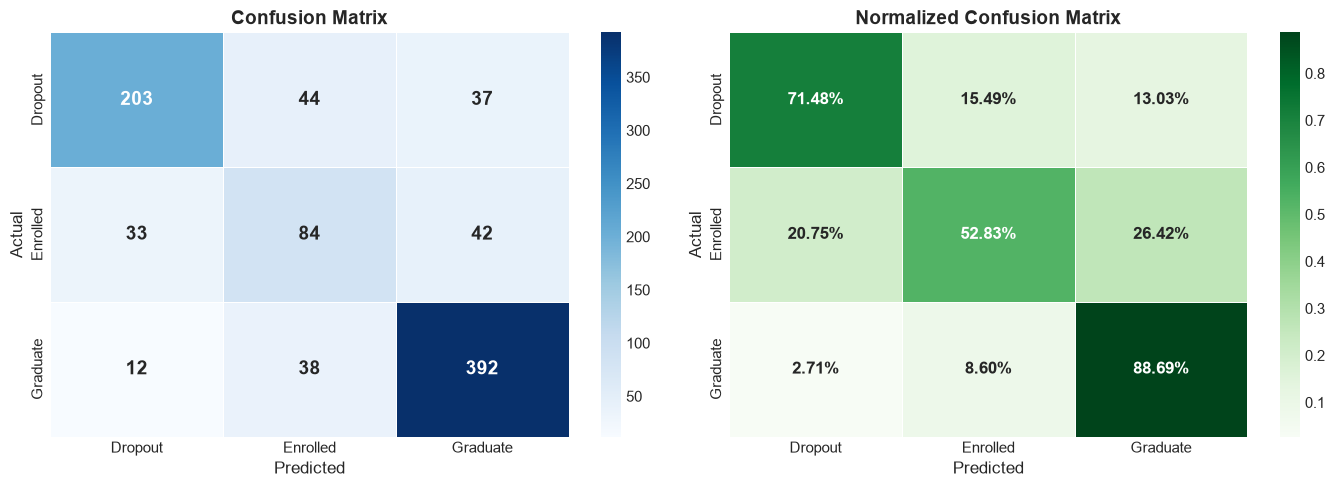


Analisis Confusion Matrix:
- Dropout: 203 dari 284 terdeteksi benar (71.5%)
- Enrolled: 84 dari 159 terdeteksi benar (52.8%)
- Graduate: 392 dari 442 terdeteksi benar (88.7%)


In [16]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Heatmap
cm = confusion_matrix(y_test, y_pred_final)
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 14, 'fontweight': 'bold'})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# 2. Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ax = axes[1]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 12, 'fontweight': 'bold'})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAnalisis Confusion Matrix:")
print(f"- Dropout: {cm[0][0]} dari {cm[0].sum()} terdeteksi benar ({cm_norm[0][0]*100:.1f}%)")
print(f"- Enrolled: {cm[1][1]} dari {cm[1].sum()} terdeteksi benar ({cm_norm[1][1]*100:.1f}%)")
print(f"- Graduate: {cm[2][2]} dari {cm[2].sum()} terdeteksi benar ({cm_norm[2][2]*100:.1f}%)")

### Feature Importance

Feature importance menunjukkan fitur mana yang paling berpengaruh dalam prediksi model. Informasi ini sangat berguna untuk memahami faktor-faktor utama penyebab dropout.

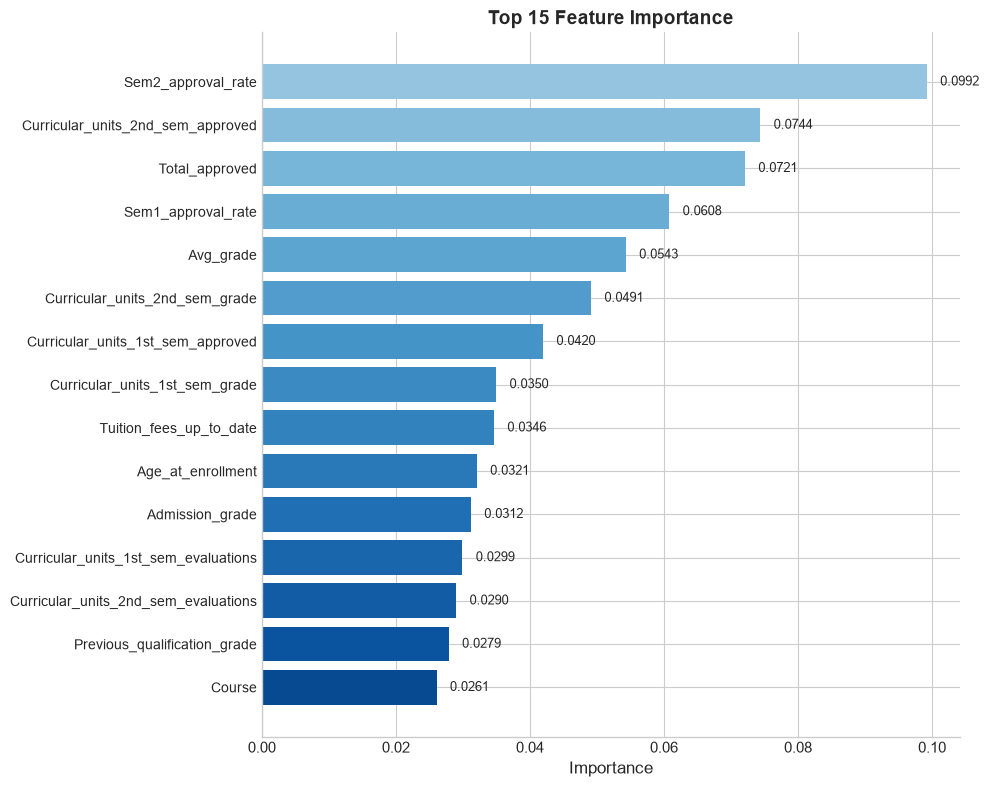


Top 10 Feature Importance:
  Sem2_approval_rate                            0.0992
  Curricular_units_2nd_sem_approved             0.0744
  Total_approved                                0.0721
  Sem1_approval_rate                            0.0608
  Avg_grade                                     0.0543
  Curricular_units_2nd_sem_grade                0.0491
  Curricular_units_1st_sem_approved             0.0420
  Curricular_units_1st_sem_grade                0.0350
  Tuition_fees_up_to_date                       0.0346
  Age_at_enrollment                             0.0321

Insight Kunci:
- Rasio approval dan grade semester 1 & 2 merupakan prediktor terkuat
- Status pembayaran SPP (Tuition_fees_up_to_date) juga sangat penting
- Usia saat mendaftar berperan signifikan dalam prediksi


In [17]:
# Feature Importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Plot top 15
    top15 = feat_imp.head(15)
    fig, ax = plt.subplots(figsize=(10, 8))
    colors_grad = plt.cm.Blues(np.linspace(0.4, 0.9, len(top15)))[::-1]
    bars = ax.barh(range(len(top15)), top15['Importance'].values[::-1], color=colors_grad)
    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(top15['Feature'].values[::-1], fontsize=10)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title('Top 15 Feature Importance', fontsize=14, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, top15['Importance'].values[::-1])):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Feature Importance:")
    for _, row in feat_imp.head(10).iterrows():
        print(f"  {row['Feature']:45s} {row['Importance']:.4f}")
    
    print("\nInsight Kunci:")
    print("- Rasio approval dan grade semester 1 & 2 merupakan prediktor terkuat")
    print("- Status pembayaran SPP (Tuition_fees_up_to_date) juga sangat penting")
    print("- Usia saat mendaftar berperan signifikan dalam prediksi")

### Menyimpan Model dan Artifacts

Model, scaler, dan encoder disimpan menggunakan joblib agar dapat digunakan kembali pada aplikasi Streamlit.

In [18]:
# Simpan model dan artifacts
import os
os.makedirs('model', exist_ok=True)

joblib.dump(best_model, 'model/model.joblib')
joblib.dump(scaler, 'model/scaler.joblib')
joblib.dump(le, 'model/label_encoder.joblib')
joblib.dump(feature_cols, 'model/feature_names.joblib')

print("Model dan artifacts berhasil disimpan:")
print("  - model/model.joblib")
print("  - model/scaler.joblib")
print("  - model/label_encoder.joblib")
print("  - model/feature_names.joblib")

# Simpan feature importance
if hasattr(best_model, 'feature_importances_'):
    feat_imp.to_csv('model/feature_importance.csv', index=False)
    print("  - model/feature_importance.csv")

print("\nSemua artifacts berhasil disimpan! Siap digunakan di aplikasi Streamlit.")

Model dan artifacts berhasil disimpan:
  - model/model.joblib
  - model/scaler.joblib
  - model/label_encoder.joblib
  - model/feature_names.joblib
  - model/feature_importance.csv

Semua artifacts berhasil disimpan! Siap digunakan di aplikasi Streamlit.


## Kesimpulan

### Temuan Utama

1. **Distribusi Data:** Dari 4.424 siswa, 32.1% mengalami dropout, 49.9% lulus, dan 17.9% masih terdaftar. Terdapat class imbalance yang perlu ditangani.

2. **Faktor Kunci Dropout:**
   - **Performa Akademik** (paling dominan): Siswa dropout rata-rata hanya menyelesaikan ~2.5 mata kuliah per semester dibanding ~6.2 untuk yang lulus.
   - **Faktor Finansial**: 32% siswa dropout belum melunasi SPP, dan hanya 9% yang mendapat beasiswa.
   - **Usia**: Rata-rata usia dropout (26 tahun) lebih tinggi dari yang lulus (22 tahun).
   - **Program Studi**: Biofuel Tech, Equinculture, dan Informatics Engineering memiliki dropout rate tertinggi (>50%).

3. **Model Machine Learning:**
   - Model terbaik yang dipilih melalui perbandingan 3 algoritma dan hyperparameter tuning.
   - Model berhasil mendeteksi siswa dropout dengan baik, dengan ROC-AUC > 0.90.
   - Engineered features (approval rate, total approved, avg grade) menjadi prediktor terkuat.

4. **Sistem Deteksi Dini:** Model ini dapat diintegrasikan sebagai Early Warning System untuk mendeteksi siswa berisiko dropout sejak semester pertama.